# **Laboratorio 02 - ejercicio de programación Regresión Lineal Multiple**

**Nombre del alumno**: Nisse Maximiliano Martinez Pardo \
**Link a github del laboratorio**: https://github.com/nmmartinezp/SIS420-Inteligencia-Artifical---NMMP/tree/master/Laboratorios/Laboratorio%2002

## Contexto del dataset

Conjunto de datos sintéticos de transacciones criptográficas que simulan comportamientos fraudulentos y legítimos del mundo real en múltiples cadenas de bloques. Ideal para la detección de fraudes, la detección de anomalías, el aprendizaje automático y el análisis exploratorio de datos

## Librerias usadas

In [5]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

## Cargar datos del csv - Crypto Scam Transaction Dataset

In [6]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [36]:
# Cargar datos
df = pd.read_csv('/content/gdrive/MyDrive/Uni_Arch/SIS420/datasets/crypto_scam_transaction_dataset.csv')

# Columnas a utilizar
columnas = [
    'sender_wallet_age_days',
    'receiver_wallet_age_days',
    'transaction_amount_usd',
    'gas_fee_usd',
    'num_prev_transactions_sender',
    'num_prev_transactions_receiver',
    'failed_txn_ratio_sender',
    'is_scam'
]

df_modelo = df[columnas].copy()

# 1. Reemplazar valores vacíos o ',' por NaN
df_modelo = df_modelo.replace(',', np.nan)
df_modelo = df_modelo.replace('', np.nan)

# 2. Convertir valores a numerico o NaN
for col in df_modelo.columns:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

# 3. Rellenar NaN con la media de cada columna
for col in df_modelo.columns:
    media = df_modelo[col].mean()
    df_modelo[col] = df_modelo[col].fillna(media)

# 4. Separar X e y
X = df_modelo.drop('is_scam', axis=1).values
y = df_modelo['is_scam'].values # columna que nos mostrara el resultado de la deteccion
m = y.size

# Muestra de datos 10 primeras filas
print(df_modelo.head(10))
print("\n")

# Tamaño de filas
print(m)

   sender_wallet_age_days  receiver_wallet_age_days  transaction_amount_usd  \
0                     469                       769                  929.39   
1                    1076                      1238                  139.21   
2                     679                       442                  395.21   
3                    1573                      2434                 2078.90   
4                     522                       418                   72.47   
5                     130                       820                  372.58   
6                      11                        74                  106.38   
7                     228                         3                  707.13   
8                      38                        13                  793.81   
9                     313                      1112                   76.16   

   gas_fee_usd  num_prev_transactions_sender  num_prev_transactions_receiver  \
0         2.76                          1120      

## Metodo 1 - Descenso por el gradiente

### Normalización

In [24]:
def  featureNormalize(X):

    X_norm = X.copy()

    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [28]:
X_norm, mu, sigma = featureNormalize(X)

print(X)
print(X_norm)
print('\n')
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

[[4.6900e+02 7.6900e+02 9.2939e+02 ... 1.1200e+03 9.6000e+02 1.8000e-01]
 [1.0760e+03 1.2380e+03 1.3921e+02 ... 1.2030e+03 1.0110e+03 1.0000e-02]
 [6.7900e+02 4.4200e+02 3.9521e+02 ... 1.1600e+03 1.0540e+03 1.4000e-01]
 ...
 [2.1500e+02 1.3200e+02 4.6635e+02 ... 1.1950e+03 1.0020e+03 1.3000e-01]
 [3.2500e+02 2.7800e+02 4.4027e+02 ... 1.1500e+03 9.9600e+02 5.0000e-02]
 [4.1400e+02 9.0400e+02 1.5705e+03 ... 1.1880e+03 1.0150e+03 1.9000e-01]]
[[-0.22623595  0.53139894  0.16984163 ... -2.31365526 -1.27685116
   0.42013791]
 [ 0.78621552  1.46032733 -0.56470506 ...  0.08693912  0.34113693
  -1.46560471]
 [ 0.12403556 -0.11627609 -0.32672896 ... -1.15674231  1.70532296
  -0.02356624]
 ...
 [-0.64989769 -0.73027993 -0.26059763 ... -0.14444347  0.05560962
  -0.13449227]
 [-0.46642213 -0.44110393 -0.28484145 ... -1.44597055 -0.13474192
  -1.02190056]
 [-0.31797373  0.79878771  0.76581372 ... -0.34690324  0.46803795
   0.53106394]]


Media calculada: [6.04636350e+02 5.00705800e+02 7.46684852e+02

In [34]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X_final = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(X_final)

[[ 1.         -0.22623595  0.53139894 ... -2.31365526 -1.27685116
   0.42013791]
 [ 1.          0.78621552  1.46032733 ...  0.08693912  0.34113693
  -1.46560471]
 [ 1.          0.12403556 -0.11627609 ... -1.15674231  1.70532296
  -0.02356624]
 ...
 [ 1.         -0.64989769 -0.73027993 ... -0.14444347  0.05560962
  -0.13449227]
 [ 1.         -0.46642213 -0.44110393 ... -1.44597055 -0.13474192
  -1.02190056]
 [ 1.         -0.31797373  0.79878771 ... -0.34690324  0.46803795
   0.53106394]]


### Aplicando del descenso por el gradiente

In [37]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = 0

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

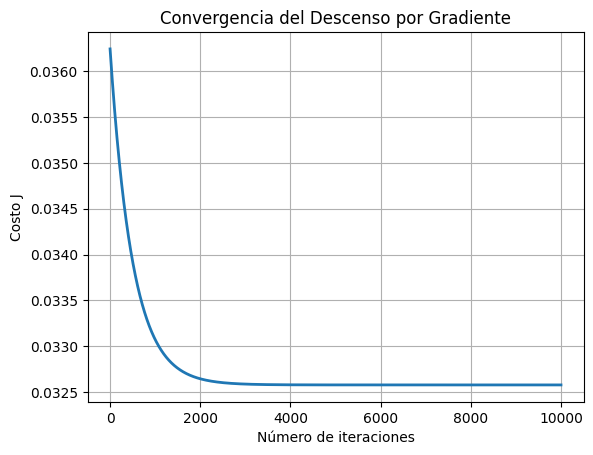

Theta calculado por el descenso por el gradiente:
  θ0 = 0.072497
  θ1 = -0.019562
  θ2 = -0.002712
  θ3 = 0.003666
  θ4 = 0.003194
  θ5 = -0.000425
  θ6 = -0.001260
  θ7 = 0.040809


In [49]:
# Elegir alpha (tasa de aprendizaje)
alpha = 0.001  # Puedes probar: 0.001, 0.01, 0.03, 0.1
num_iters = 10000

# Inicializar theta (7 características + 1 intercept = 8)
theta = np.zeros(X_final.shape[1])  # X_final.shape[1] = 8

# Ejecutar descenso por el gradiente
theta, J_history = gradientDescentMulti(X_final, y, theta, alpha, num_iters)

# Graficar la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por Gradiente')
pyplot.grid(True)
pyplot.show()

# Mostrar los theta calculados
print('Theta calculado por el descenso por el gradiente:')
for i, val in enumerate(theta):
    print(f'  θ{i} = {val:.6f}')

### Ejemplos

In [54]:
# PREDICCIÓN PARA UNA NUEVA TRANSACCIÓN
# Ejemplo: Vamos a predecir si una transacción es scam

# Datos de una transacción hipotética (SIN normalizar)
# [edad_envia, edad_recibe, monto_usd, gas_fee, hist_envia, hist_recibe, ratio_fallos]

# nueva_transaccion = [10, 5, 5000, 1.5, 5, 3, 0.85]  # Características de una transacción SOSPECHOSA
nueva_transaccion = [0, 0, 50000, 0.01, 0, 0, 0.99] # Características de una transacción SOSPECHOSA
# nueva_transaccion = [1000, 800, 50, 5.0, 500, 400, 0.01] # Características de una transacción SEGURA
# nueva_transaccion = [300, 350, 500, 8.0, 100, 80, 0.10] # Características de una transacción NORMAL
# nueva_transaccion = [800, 750, 15000, 12.0, 600, 500, 0.05] # Características de una transacción MONTO ALTO
# nueva_transaccion = [2, 3, 20, 2.0, 2, 1, 0.02] # Características de una transacción CUENTAS NUEVAS
# nueva_transaccion = [900, 850, 1000, 3.0, 200, 180, 0.85] # Características de una transacción ALTO RATIO DE FALLOS
# nueva_transaccion = [0, 0, 100000, 0.001, 0, 0, 1.0] # Características de una transacción EXTREMA

# 1. Normalizar los datos (usando mu y sigma de tu entrenamiento)
nueva_transaccion_norm = (nueva_transaccion - mu) / sigma

# 2. Agregar el intercept (1 al principio)
X_nueva = np.concatenate([[1], nueva_transaccion_norm])

# 3. Predecir (scam_probability)
scam_probability = np.dot(X_nueva, theta)

# 4. Interpretar el resultado
print('\n' + '='*50)
print('PREDICCIÓN DE TRANSACCIÓN FRAUDULENTA')
print('='*50)
print(f'Datos de la transacción:')
print(f'  - Edad del remitente: {nueva_transaccion[0]} días')
print(f'  - Edad del receptor: {nueva_transaccion[1]} días')
print(f'  - Monto: ${nueva_transaccion[2]:.2f} USD')
print(f'  - Comisión: ${nueva_transaccion[3]:.2f} USD')
print(f'  - Historial del remitente: {nueva_transaccion[4]} transacciones')
print(f'  - Historial del receptor: {nueva_transaccion[5]} transacciones')
print(f'  - Ratio de fallos del remitente: {nueva_transaccion[6]*100:.1f}%')
print(f'\nProbabilidad de ser SCAM: {scam_probability:.4f}')

# Decisión (umbral 0.5)
if scam_probability >= 0.5:
    print('\n🚨 ¡ALERTA! Esta transacción tiene ALTA probabilidad de ser FRAUDULENTA')
else:
    print('\n✅ Esta transacción parece SEGURA')


PREDICCIÓN DE TRANSACCIÓN FRAUDULENTA
Datos de la transacción:
  - Edad del remitente: 0 días
  - Edad del receptor: 0 días
  - Monto: $50000.00 USD
  - Comisión: $0.01 USD
  - Historial del remitente: 0 transacciones
  - Historial del receptor: 0 transacciones
  - Ratio de fallos del remitente: 99.0%

Probabilidad de ser SCAM: 0.6980

🚨 ¡ALERTA! Esta transacción tiene ALTA probabilidad de ser FRAUDULENTA


## Metodo 2 - Ecuacion de la Normal

In [46]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [55]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X_final, y);

# Mostrar los theta calculados
print('Theta calculado por la ecuacion de la normal:')
for i, val in enumerate(theta):
    print(f'  θ{i} = {val:.6f}')

Theta calculado por la ecuacion de la normal:
  θ0 = 0.072500
  θ1 = -0.019563
  θ2 = -0.002712
  θ3 = 0.003667
  θ4 = 0.003194
  θ5 = -0.000424
  θ6 = -0.001261
  θ7 = 0.040810


### Ejemplos

In [53]:
# PREDICCIÓN PARA UNA NUEVA TRANSACCIÓN
# Ejemplo: Vamos a predecir si una transacción es scam

# Datos de una transacción hipotética (SIN normalizar)
# [edad_envia, edad_recibe, monto_usd, gas_fee, hist_envia, hist_recibe, ratio_fallos]

# nueva_transaccion = [10, 5, 5000, 1.5, 5, 3, 0.85]  # Características de una transacción sospechosa
nueva_transaccion = [0, 0, 50000, 0.01, 0, 0, 0.99] # Características de una transacción SOSPECHOSA
# nueva_transaccion = [1000, 800, 50, 5.0, 500, 400, 0.01] # Características de una transacción SEGURA
# nueva_transaccion = [300, 350, 500, 8.0, 100, 80, 0.10] # Características de una transacción NORMAL
# nueva_transaccion = [800, 750, 15000, 12.0, 600, 500, 0.05] # Características de una transacción MONTO ALTO
# nueva_transaccion = [2, 3, 20, 2.0, 2, 1, 0.02] # Características de una transacción CUENTAS NUEVAS
# nueva_transaccion = [900, 850, 1000, 3.0, 200, 180, 0.85] # Características de una transacción ALTO RATIO DE FALLOS
# nueva_transaccion = [0, 0, 100000, 0.001, 0, 0, 1.0] # Características de una transacción EXTREMA

# 1. Normalizar los datos (usando mu y sigma de tu entrenamiento)
nueva_transaccion_norm = (nueva_transaccion - mu) / sigma

# 2. Agregar el intercept (1 al principio)
X_nueva = np.concatenate([[1], nueva_transaccion_norm])

# 3. Predecir (scam_probability)
scam_probability = np.dot(X_nueva, theta)

# 4. Interpretar el resultado
print('\n' + '='*50)
print('PREDICCIÓN DE TRANSACCIÓN FRAUDULENTA')
print('='*50)
print(f'Datos de la transacción:')
print(f'  - Edad del remitente: {nueva_transaccion[0]} días')
print(f'  - Edad del receptor: {nueva_transaccion[1]} días')
print(f'  - Monto: ${nueva_transaccion[2]:.2f} USD')
print(f'  - Comisión: ${nueva_transaccion[3]:.2f} USD')
print(f'  - Historial del remitente: {nueva_transaccion[4]} transacciones')
print(f'  - Historial del receptor: {nueva_transaccion[5]} transacciones')
print(f'  - Ratio de fallos del remitente: {nueva_transaccion[6]*100:.1f}%')
print(f'\nProbabilidad de ser SCAM: {scam_probability:.4f}')

# Decisión (umbral 0.5)
if scam_probability >= 0.5:
    print('\n🚨 ¡ALERTA! Esta transacción tiene ALTA probabilidad de ser FRAUDULENTA')
else:
    print('\n✅ Esta transacción parece SEGURA')


PREDICCIÓN DE TRANSACCIÓN FRAUDULENTA
Datos de la transacción:
  - Edad del remitente: 0 días
  - Edad del receptor: 0 días
  - Monto: $50000.00 USD
  - Comisión: $0.01 USD
  - Historial del remitente: 0 transacciones
  - Historial del receptor: 0 transacciones
  - Ratio de fallos del remitente: 99.0%

Probabilidad de ser SCAM: 0.6980

🚨 ¡ALERTA! Esta transacción tiene ALTA probabilidad de ser FRAUDULENTA
